# Part 3 통합 — AWS 실측기온 기반 위성 LST 검증 (전체 파이프라인)

2026-08-31 2개 노트북을 실행 순서대로 하나로 합친 버전. 원본은 각각 별도 파일로 남아있고, 이 노트북은 전체 흐름을 한 번에 보고 재현하기 위한 통합본이다.

**실행 순서 (파일 의존성 기준)**

| 구간 | 원본 노트북 | 역할 | 핵심 산출물 |
|---|---|---|---|
| A | `part3_day_lst_export.ipynb` | 파트1과 동일한 씬 필터로 주간 LST 씬별 스택을 만든다 (AWS 검증용 원본 온도 데이터). | 주간 LST 스택 + index.csv |
| B | `part3_aws_validation.ipynb` | 구간 A의 주간 LST 스택과 AWS 실측기온을 대조해 상관 r을 산출한다. | 검증 상관계수 · 보고서 문장 |

구간 B는 구간 A가 만든 주간 LST 씬별 스택을 읽어서 쓰므로 반드시 구간 A 다음에 실행해야 한다. 구간 경계에서 `%reset -f`로 네임스페이스를 초기화해 앞 구간 변수가 뒷 구간에 실수로 섞여 들어가지 않게 했다.


---
# 구간 A. 주간 LST 씬별 스택
**원본: `part3_day_lst_export.ipynb`**

파트1과 동일한 씬 필터로 주간 LST 씬별 스택을 만든다. AWS 검증(구간 B)의 입력 데이터가 된다.

# 파트 1 부속 — 주간 LST 씬별 스택 (파트 3 AWS 검증용)

`part1_LST_final.ipynb`의 `[9] AWS 검증용 스택`은 야간(ECOSTRESS)만 만들었고, 주간(Landsat)은 합성 결과(median/p90/anomaly)만 있어 파트3의 주간 r 계산이 불가능했다. 이 노트북은 파트1과 **동일한 Landsat 8/9 씬 모집단·같은 QA_PIXEL 클리어마스크**로 씬별 LST를 개별 밴드로 저장해 야간 스택과 대칭인 산출물을 만든다.

산출물 (파트1 자리에 저장 — `data/part1/processed/`):
- `busan_lst_day_stack_100m.tif` — 씬별 LST, 밴드마다 관측 하나
- `busan_lst_day_stack_index.csv` — 밴드 ↔ 관측시각(KST) 대응표, 야간 index.csv와 동일 스키마

In [1]:
import ee, geemap
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

import os; GCP_PROJECT = os.environ.get("GEE_PROJECT", "your-gcp-project-id")
try:
    ee.Initialize(project=GCP_PROJECT)
except Exception:
    ee.Authenticate(); ee.Initialize(project=GCP_PROJECT)

# ── 파트1과 동일한 상수 (part1_LST_final.ipynb [0] 설정 그대로) ──────────────
BUSAN_BBOX   = (128.74, 34.85, 129.32, 35.42)     # W,S,E,N EPSG:4326
CRS_ANALYSIS = "EPSG:5186"
TARGET_RES_M = 100
DAY_YEARS       = [2021, 2022, 2023, 2024, 2025]
SCENE_CLOUD_MAX = 80
COLLECTIONS     = ["LANDSAT/LC08/C02/T1_L2", "LANDSAT/LC09/C02/T1_L2"]

# ── 프로젝트 공통 격자 (파트1/2/4와 완전히 동일) ─────────────────────────────
WIDTH, HEIGHT = 542, 644
GRID_BOUNDS   = (358000.0, 251800.0, 412200.0, 316200.0)   # xmin,ymin,xmax,ymax
TRANSFORM = rasterio.transform.from_origin(GRID_BOUNDS[0], GRID_BOUNDS[3],
                                           TARGET_RES_M, TARGET_RES_M)

P1 = Path("../data/part1")
RAW_SCENES = P1 / "raw" / "landsat" / "day_scenes"      # 씬별 원본 캐시
OUT_DIR    = P1 / "processed"
RAW_SCENES.mkdir(parents=True, exist_ok=True)
OUT_STACK  = OUT_DIR / "busan_lst_day_stack_100m.tif"
OUT_INDEX  = OUT_DIR / "busan_lst_day_stack_index.csv"
LAND_TIF   = OUT_DIR / "busan_land_100m.tif"             # 파트1이 이미 만든 육지마스크 재사용

AOI = ee.Geometry.Rectangle(list(BUSAN_BBOX), "EPSG:4326", False)
print("격자:", CRS_ANALYSIS, TARGET_RES_M, f"{WIDTH}x{HEIGHT}", GRID_BOUNDS)


격자: EPSG:5186 100 542x644 (358000.0, 251800.0, 412200.0, 316200.0)


## 씬 모집단 구성 — 파트1과 완전히 동일한 필터

`LC08/LC09 · 6~8월 · 2021~2025 · CLOUD_COVER<80` — 파트1 `[4] 주간 LST`가 합성에 쓴 것과 같은 77개 씬 모집단. QA_PIXEL 클리어마스크(구름·구름그림자·눈 비트 제외)와 DN→°C 변환도 파트1의 `prep()` 함수를 그대로 재현한다.

In [2]:
col = None
for cid in COLLECTIONS:
    x = (ee.ImageCollection(cid).filterBounds(AOI)
         .filter(ee.Filter.calendarRange(6, 8, "month"))
         .filter(ee.Filter.calendarRange(min(DAY_YEARS), max(DAY_YEARS), "year"))
         .filter(ee.Filter.lt("CLOUD_COVER", SCENE_CLOUD_MAX)))
    col = x if col is None else col.merge(x)
n_scenes = col.size().getInfo()
print(f"씬 모집단 {n_scenes}개 (파트1과 동일 필터)")


def _bit(qa, b):
    return qa.rightShift(b).bitwiseAnd(1)


def prep(img):
    """파트1 prep(img, stqa_filter=False)과 동일 — QA_PIXEL 클리어마스크 + DN→°C."""
    qa = img.select("QA_PIXEL")
    clear = (_bit(qa, 0).eq(0).And(_bit(qa, 1).eq(0)).And(_bit(qa, 2).eq(0))
             .And(_bit(qa, 3).eq(0)).And(_bit(qa, 4).eq(0)).And(_bit(qa, 5).eq(0)))
    m = clear.And(img.select("ST_B10").gt(0))
    lst = (img.select("ST_B10").multiply(0.00341802).add(149.0).subtract(273.15)
           .rename("LST"))
    return lst.updateMask(m).set("system:time_start", img.get("system:time_start"),
                                  "system:index", img.get("system:index"))


# 씬 메타(시각·id) 목록을 먼저 한 번에 받아온다
scene_meta = (col.map(lambda im: ee.Feature(None, {
    "index": im.get("system:index"),
    "time_start": im.get("system:time_start"),
})).toList(n_scenes).getInfo())
scene_ids = [f["properties"]["index"] for f in scene_meta]
scene_ts  = [f["properties"]["time_start"] for f in scene_meta]
print(f"메타 {len(scene_ids)}건 수신, 예: {scene_ids[0]} @ {scene_ts[0]}")


씬 모집단 77개 (파트1과 동일 필터)


메타 77건 수신, 예: 1_LC08_114035_20210604 @ 1622771931501


## 씬별 다운로드 — 야간 스택과 같은 방식(로컬 다중밴드 스택)

77개 씬을 하나씩 `geemap.download_ee_image()`로 100m/EPSG:5186 그리드에 직접 받는다 (파트1 야간 스택·파트4 NDVI와 같은 동기 다운로드 패턴 — 격자가 작아 배치 익스포트 불필요). 받은 각 씬은 `raw/landsat/day_scenes/`에 캐시해 재실행 시 다시 받지 않는다.

In [3]:
col_list = col.toList(n_scenes)
bands = []
kept_ids, kept_ts = [], []
skipped = 0

for i, (sid, ts) in enumerate(zip(scene_ids, scene_ts)):
    fp = RAW_SCENES / f"{sid}.tif"
    if not fp.exists():
        img = prep(ee.Image(col_list.get(i)))
        try:
            geemap.download_ee_image(img, filename=str(fp), region=AOI.bounds(),
                                     scale=TARGET_RES_M, crs=CRS_ANALYSIS, dtype="float32")
        except Exception as e:
            print(f"[skip] {sid}: 다운로드 실패 ({type(e).__name__}: {e})")
            skipped += 1
            continue
    with rasterio.open(fp) as s:
        a = s.read(1).astype("float32")
        if s.nodata is not None and not np.isnan(s.nodata):
            a[a == s.nodata] = np.nan
        if a.shape != (HEIGHT, WIDTH):
            print(f"[skip] {sid}: shape {a.shape} != ({HEIGHT},{WIDTH})")
            skipped += 1
            continue
    bands.append(a)
    kept_ids.append(sid)
    kept_ts.append(ts)
    if (i + 1) % 15 == 0:
        print(f"  {i+1}/{n_scenes}")

print(f"\n완료: {len(bands)}밴드 확보, 스킵 {skipped}개")


C:\Users\<USER>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\geemap\common.py:12263: FutureWarning: 'BaseImage' is deprecated and will be removed in a future release.  Please use the 'ee.Image.gd' accessor instead.
  img = gd.download.BaseImage(image)


1_LC08_114035_20210604:   0%|          |0/1 tiles [00:00<?]

C:\Users\<USER>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\geedim\image.py:254: RuntimeWarning: Couldn't find STAC entry for: 'None'.
  return STACClient().get(self.id)


1_LC08_114035_20210620:   0%|          |0/1 tiles [00:00<?]

1_LC08_114035_20210722:   0%|          |0/1 tiles [00:00<?]

...

2_LC09_114036_20250709:   0%|          |0/1 tiles [00:00<?]

  75/77


2_LC09_114036_20250725:   0%|          |0/1 tiles [00:00<?]

2_LC09_114036_20250826:   0%|          |0/1 tiles [00:00<?]


완료: 77밴드 확보, 스킵 0개


## 스택 저장 + index.csv 생성

컬럼은 야간 `busan_lst_night_stack_index.csv`와 같은 스키마(`obs, kst, kst_hour, year, date, cov, band`)로 맞춘다 — 파트3 노트북의 `load_index()`가 두 센서를 같은 코드로 처리할 수 있도록.

In [4]:
cube = np.stack(bands)                       # (n_scenes, H, W)

# 육지마스크 대비 커버리지 (야간 index의 cov와 같은 정의)
with rasterio.open(LAND_TIF) as s:
    land = s.read(1)
    land_mask = (land == 1) if s.nodata is None else (land == 1) & (land != s.nodata)
n_land = int(land_mask.sum())
cov = [float(np.isfinite(b)[land_mask].sum()) / n_land for b in bands]

kst = pd.to_datetime(kept_ts, unit="ms", utc=True).tz_convert("Asia/Seoul").tz_localize(None)
idx = pd.DataFrame({
    "obs": kept_ids,
    "kst": kst,
    "kst_hour": kst.hour + kst.minute / 60,
    "year": kst.year,
    "date": kst.date,
    "cov": cov,
})
idx["band"] = range(1, len(idx) + 1)

with rasterio.open(OUT_STACK, "w", driver="GTiff", height=HEIGHT, width=WIDTH,
                   count=len(bands), dtype="float32", crs=CRS_ANALYSIS,
                   transform=TRANSFORM, nodata=np.nan,
                   compress="deflate", tiled=True) as d:
    for i, (a, sid) in enumerate(zip(bands, kept_ids), 1):
        d.write(a, i); d.set_band_description(i, sid)

idx.to_csv(OUT_INDEX, index=False, encoding="utf-8-sig")

print(f"저장: {OUT_STACK} ({len(bands)}밴드)")
print(f"저장: {OUT_INDEX}")
print(f"\n관측시각 분포(KST 시): {idx.kst_hour.round().value_counts().sort_index().to_dict()}")
print(f"커버리지 중앙값 {np.median(cov):.1%}, 0인 씬 {sum(c==0 for c in cov)}개")
print(f"기간: {idx.kst.min()} ~ {idx.kst.max()}")


저장: ..\data\part1\processed\busan_lst_day_stack_100m.tif (77밴드)
저장: ..\data\part1\processed\busan_lst_day_stack_index.csv

관측시각 분포(KST 시): {11.0: 77}
커버리지 중앙값 47.0%, 0인 씬 3개
기간: 2021-06-04 10:58:51.501000 ~ 2025-08-26 10:59:36.672000


## 검산

In [5]:
with rasterio.open(OUT_STACK) as s:
    print("shape:", (s.count, s.height, s.width), "| crs:", s.crs, "| transform:", s.transform)
    assert (s.height, s.width) == (HEIGHT, WIDTH), "격자 크기 불일치"
    assert str(s.crs).endswith("5186"), "CRS 불일치"

# 밤 시간대(08~18시 KST)가 섞여 있으면 이상 — Landsat은 11시대여야 정상
odd = ((idx.kst_hour < 8) | (idx.kst_hour > 16)).sum()
print(f"비정상 통과시각(11시대 밖) {odd}건 / {len(idx)}건")
assert odd == 0, "Landsat 통과시각이 11시대를 벗어남 — 시간대 변환 재확인 필요"
print("[ok] 전 씬 정상 시각대 (10~12시대)")


shape: (77, 644, 542) | crs: EPSG:5186 | transform: | 100.00, 0.00, 358000.00|
| 0.00,-100.00, 316200.00|
| 0.00, 0.00, 1.00|
비정상 통과시각(11시대 밖) 0건 / 77건
[ok] 전 씬 정상 시각대 (10~12시대)


In [1]:
%reset -f
# 2026-08-31: 노트북 병합 시 앞 파트의 변수가 뒷 파트로 잘못 넘어가지 않도록
# 구간마다 네임스페이스를 완전히 초기화한다 (각 파트는 원래 독립 커널에서 돌던
# 노트북이라 파일 입출력으로만 서로 연결되고, 변수 재사용을 전제하지 않는다).


---
# 구간 B. AWS 실측기온 검증 (메인)
**원본: `part3_aws_validation.ipynb`**

구간 A의 주간 LST 스택과 AWS 실측기온을 시각·지점 단위로 대조해 상관 r을 산출하고, 파트5로 인계할 문장을 만든다.

# 파트 3 — AWS 실측기온으로 위성 LST 검증

**2026 부산광역시 빅데이터 활용 경진대회 · 가이드라인 Step 0**

산출 목표

1. `r_night_all / r_night_inland / r_day_all / r_day_inland` — 상관계수 4종
2. `lapse_aws_night` — AWS 고도별 기온 감률 (파트 1 위성 감률 −0.496 °C/100m 과 비교)
3. 폭염일수 · 열대야일수 확정치 (가이드라인 1-1의 "재확인 필요" 각주 제거용)

산출물: `part3_stations.csv` · `part3_matchup.parquet` · `part3_summary.json` · `reports/part3_scatter.png`

> **상태: 데이터 미확보.** 경로 상수(2번 셀)와 컬럼 매핑(`COLMAP`)만 실제 파일에 맞게 고치면 위에서 아래로 실행됩니다.
> 각 단계 끝에 `assert` 검산이 붙어 있으니, 조용히 틀리는 대신 그 자리에서 멈춥니다.

## 0. 환경 · 상수

```bash
pip install numpy pandas geopandas rasterio pyproj h3 scipy matplotlib pyarrow
```

In [2]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

# ── 경로 ────────────────────────────────────────────────────────────────────
ROOT      = Path("../data")            # 프로젝트 데이터 루트 (2026-08-16: notebooks/ 로 이동)
P1        = ROOT / "part1"            # 파트 1 산출물
RAW_KMA   = ROOT / "raw" / "kma"      # 기상청 포털에서 받은 원본 CSV
OUT       = ROOT / "part3"            # 이 노트북의 산출물
REPORTS   = OUT / "reports"
OUT.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

# 2026-08-18: 8/16 재정비 이후 파트1 산출물 경로가 processed/tables 하위로 바뀐 것 반영,
# 주간 스택은 part3_day_lst_export.ipynb에서 새로 만든 것을 사용
PATH_NIGHT_STACK = P1 / "processed" / "busan_lst_night_stack_100m.tif"   # ECOSTRESS 야간 개별 관측 ~30밴드
PATH_DAY_STACK   = P1 / "processed" / "busan_lst_day_stack_100m.tif"     # Landsat 주간 씬별 LST (신규)
PATH_INDEX_NIGHT = P1 / "processed" / "busan_lst_night_stack_index.csv"  # 밴드 ↔ 관측시각
PATH_INDEX_DAY   = P1 / "processed" / "busan_lst_day_stack_index.csv"    # 밴드 ↔ 관측시각 (신규)
PATH_P1_META     = P1 / "part1_meta.json"                  # 없으면 아래 check_grid_matches_part1()이 생략
PATH_HEX         = P1 / "tables" / "part1_lst_hex_r10.parquet"          # 파트 1 hex 테이블 (dist_water_m 사용)

PATH_AWS_HOURLY   = ROOT / "part3" / "AWS" / "aws_merged_2020_2025.csv"  # 2026-08-16: data/AWS -> data/part3/AWS             # 지상 > 방재기상관측(AWS) 시간자료 (12지점 병합본, stn_id/tm/ta만 사용)
PATH_AWS_STN_HIST = ROOT / "part3" / "AWS" / "META_관측지점정보_20260806145821.csv"   # 관측지점정보 — 지점 이전·고도 갱신 이력 (시작일~종료일 구간별로 여러 행)
PATH_ASOS_DAILY   = ROOT / "part3" / "ASOS_2016_2025_guideline.csv"      # 2026-08-18: 신규 도착 — 부산(159) 10년 일최고/일최저 (tm,tmax,tmin 그대로 사용 가능)

# ── 격자 규격 (파트 1과 반드시 동일) ────────────────────────────────────────
CRS_GRID   = "EPSG:5186"
CRS_WGS84  = "EPSG:4326"
GRID_RES   = 100
GRID_W, GRID_H = 542, 644
GRID_BOUNDS    = (358000.0, 251800.0, 412200.0, 316200.0)   # xmin, ymin, xmax, ymax
H3_RES     = 10

# ── 파트 1이 만든 감률 (비교 대상) ──────────────────────────────────────────
LAPSE_P1_NIGHT = -0.4961    # °C / 100m
LAPSE_P1_DAY   = -1.3678

# ── 분석 파라미터 ───────────────────────────────────────────────────────────
WIN            = 1        # 3x3 창 반경 (1 → 3x3)
MIN_VALID_PX   = 5        # 3x3 중 유효 픽셀 최소 개수 (가이드 3단계 규칙)
MAX_GAP_H      = 1.5      # AWS 보간 시 허용하는 앞/뒤 관측 최대 간격(시간)
MIN_PAIRS_SCENE = 5       # 장면별 r 계산 최소 쌍 수
MIN_PAIRS_STN   = 5       # 지점별 통계 최소 쌍 수
COASTAL_DIST_M = 500      # 해안 지점 판정 임계 (dist_water_m 기준)
NIGHT_HOURS    = list(range(21, 24)) + list(range(0, 6))   # 감률 산출용 야간 정의 21~05시
SUMMER_MONTHS  = (6, 7, 8)
HEATWAVE_TMAX  = 33.0     # 폭염일 기준
TROPICAL_TMIN  = 25.0     # 열대야 기준

# ── 원본 CSV 컬럼명 매핑 (포털 다운로드 형식에 맞게 여기만 고치면 됨) ──────
COLMAP = {
    "aws_hourly":   {"stn_id": "지점", "tm": "일시", "ta": "기온(°C)"},
    "aws_stn_hist": {"stn_id": "지점", "stn_name": "지점명", "lon": "경도", "lat": "위도",
                     "elev_m": "노장해발고도(m)", "period_start": "시작일", "period_end": "종료일"},
    "asos_daily":   {"tm": "일시", "tmax": "최고기온(°C)", "tmin": "최저기온(°C)"},
    "index":        {"band": "band", "time_kst": "obs_time_kst", "time_utc": "obs_time_utc"},
}

print("격자:", CRS_GRID, GRID_RES, f"{GRID_W}x{GRID_H}", GRID_BOUNDS)

격자: EPSG:5186 100 542x644 (358000.0, 251800.0, 412200.0, 316200.0)


In [3]:
def read_csv_kma(path: Path, colmap: dict, required=()) -> pd.DataFrame:
    """기상청 포털 CSV 로더. 인코딩(cp949/utf-8-sig)과 컬럼명 변형을 흡수한다."""
    last = None
    for enc in ("utf-8-sig", "cp949", "euc-kr"):
        try:
            df = pd.read_csv(path, encoding=enc)
            break
        except UnicodeDecodeError as e:
            last = e
    else:
        raise last

    df.columns = [str(c).strip() for c in df.columns]
    ren = {}
    for std, raw in colmap.items():
        if raw in df.columns:
            ren[raw] = std
        else:
            # 부분 일치 폴백 ("기온(°C)" ↔ "기온" 등 표기 흔들림 대응)
            cand = [c for c in df.columns if raw.split("(")[0] in c]
            if cand:
                ren[cand[0]] = std
    df = df.rename(columns=ren)

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"{path.name}: 컬럼 매핑 실패 {missing}. 실제 컬럼={list(df.columns)}")
    return df


def check_grid_matches_part1() -> dict:
    """파트 1 메타의 격자 규격이 이 노트북 상수와 같은지 확인. 어긋나면 지점 픽셀이 밀린다."""
    if not PATH_P1_META.exists():
        print("[skip] part1_meta.json 없음 — 규격 검증 생략")
        return {}
    meta = json.loads(PATH_P1_META.read_text(encoding="utf-8"))
    g = meta.get("grid", meta)
    def _get(*keys, default=None):
        for k in keys:
            if k in g:
                return g[k]
        return default
    assert str(_get("crs", "epsg", default=CRS_GRID)).endswith("5186"), "CRS 불일치"
    assert int(_get("res", "resolution", default=GRID_RES)) == GRID_RES, "해상도 불일치"
    assert int(_get("width", default=GRID_W)) == GRID_W, "width 불일치"
    assert int(_get("height", default=GRID_H)) == GRID_H, "height 불일치"
    print("[ok] 파트 1 격자 규격 일치")
    return meta


P1_META = check_grid_matches_part1()

[skip] part1_meta.json 없음 — 규격 검증 생략


## 1단계 — 지점 준비: AWS 지점을 우리 격자에 올리기

위경도 → EPSG:5186 변환 → 파트 1과 **동일한 방식**으로 `hex_id` 부여.
관측고도와 DEM 표고를 비교해 크게 어긋나는 지점(옥상 설치 의심)을 플래그로 남긴다.
상관 계산에서 빼지 않고, 결과 해석의 각주로만 쓴다.

**시간대별(period-aware) 조인.** 관측지점정보(META)는 지점 이전·고도 갱신 이력을
`시작일~종료일` 구간별로 여러 행에 담고 있다(예: 사상 904는 2020-10-31에 ~3~4km 이동,
여러 지점이 고도값만 갱신됨). 지점번호만으로 단순 조인하면 특정 시점의 스냅샷 하나가
5년 전체에 붙어버리므로, `station_periods`(전체 이력)를 만들고 관측시각(`tm`)마다
`merge_asof`로 **그 시각에 실제로 유효했던 위경도·고도**를 붙인다.
`part3_stations.csv`처럼 지점당 한 행이 필요한 곳에는 **현재(종료일 없음) 구간**을 대표값으로 쓴다.

In [4]:
import h3
from pyproj import Transformer

TF_TO_GRID = Transformer.from_crs(CRS_WGS84, CRS_GRID, always_xy=True)
TF_TO_WGS  = Transformer.from_crs(CRS_GRID, CRS_WGS84, always_xy=True)
FAR_FUTURE = pd.Timestamp("2100-01-01")   # 종료일이 비어있는(현재도 운영 중인) 구간의 상한


def load_station_periods(keep_ids: set[int] | None = None) -> pd.DataFrame:
    """관측지점정보(META)의 지점 이전·고도 갱신 이력을 지점별 시작일 오름차순 구간표로 정리.

    포털이 주는 원본은 지점 하나가 여러 행(구간)으로 쪼개져 있다 —
    지점이 이전되거나 노장해발고도가 갱신될 때마다 새 구간이 생긴다.
    keep_ids를 주면 그 지점번호만 남긴다(META에는 ASOS 159 등 AWS 시간자료가
    아예 없는 지점도 섞여 있어, 걸러주지 않으면 커버리지 0인 지점이 station 표에 낀다).
    """
    per = read_csv_kma(PATH_AWS_STN_HIST, COLMAP["aws_stn_hist"],
                       required=("stn_id", "period_start", "lat", "lon"))
    per = per.dropna(subset=["stn_id"]).copy()          # 포털 원본 맨 위 빈 행 등 제거
    per["stn_id"] = per["stn_id"].astype("int64")  # 2026-08-18: Windows astype(int)=int32 -> merge_asof dtype 충돌 방지
    if keep_ids is not None:
        per = per[per["stn_id"].isin(keep_ids)]
    per["period_start"] = pd.to_datetime(per["period_start"], errors="coerce")
    per["period_end"] = pd.to_datetime(per.get("period_end"), errors="coerce").fillna(FAR_FUTURE)
    for c in ("lon", "lat", "elev_m"):
        if c in per:
            per[c] = pd.to_numeric(per[c], errors="coerce")

    per = per.dropna(subset=["period_start", "lat", "lon"])
    per = per.sort_values(["stn_id", "period_start"]).reset_index(drop=True)

    # 지점 안에서 구간이 빈틈없이 이어지는지 확인 — 빈틈이 있으면 그 사이 관측은 조인에서 빠진다
    for sid, g in per.groupby("stn_id"):
        gap = (g["period_start"].values[1:] != g["period_end"].values[:-1]).sum()
        if gap:
            print(f"[warn] stn {sid}: 이력 구간에 빈틈/중첩 {gap}곳 — 그 구간 관측은 조인 실패로 빠질 수 있음")
    return per


def _with_grid_coords(df: pd.DataFrame) -> pd.DataFrame:
    """lat/lon 컬럼이 있는 프레임에 x_5186/y_5186/hex_id를 붙인다. 같은 (lat,lon)은 캐싱."""
    uniq = df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)
    x, y = TF_TO_GRID.transform(uniq["lon"].values, uniq["lat"].values)
    uniq["x_5186"], uniq["y_5186"] = x, y
    uniq["hex_id"] = [h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(uniq["lat"], uniq["lon"])]
    return df.merge(uniq, on=["lat", "lon"], how="left")


def attach_time_varying_meta(obs: pd.DataFrame, periods: pd.DataFrame,
                             tm_col: str = "tm", id_col: str = "stn_id") -> pd.DataFrame:
    """obs(stn_id, tm, ...) 각 행에 그 시각(tm)에 실제로 유효했던 지점명/위경도/고도를 asof 조인으로 붙인다."""
    obs_sorted = obs.sort_values(tm_col).reset_index(drop=True)
    per_sorted = periods.sort_values("period_start").reset_index(drop=True)

    out = pd.merge_asof(obs_sorted, per_sorted, left_on=tm_col, right_on="period_start",
                        by=id_col, direction="backward")

    unmatched = out["period_start"].isna()
    if unmatched.any():
        print(f"[warn] 이력 시작일보다 이른 관측 {int(unmatched.sum())}건 — 매칭 실패로 제외")
    out = out[~unmatched].copy()

    late = out[tm_col] >= out["period_end"]
    if late.any():
        print(f"[warn] 구간 종료일을 벗어난 관측 {int(late.sum())}건 — 이력 구간 빈틈 의심, 확인 필요")

    out = out.drop(columns=["period_start", "period_end"])
    return _with_grid_coords(out).reset_index(drop=True)


def load_stations(periods: pd.DataFrame) -> pd.DataFrame:
    """part3_stations.csv 등 지점당 한 행이 필요한 곳에 쓸 대표 스냅샷.

    각 지점의 **현재(종료일 없음) 구간** — 즉 포털이 지금 돌려주는 최신 위경도/고도 — 를 쓴다.
    상관·감률 계산 본체는 이 스냅샷이 아니라 attach_time_varying_meta()로 관측시각별
    올바른 값을 붙인 aws_hourly를 쓴다(2단계 참고).
    """
    stn = (periods[periods.period_end >= FAR_FUTURE]
           .sort_values(["stn_id", "period_start"])
           .drop_duplicates("stn_id", keep="last")
           .reset_index(drop=True))
    if "elev_m" not in stn or stn.elev_m.isna().all():
        print("[warn] 관측고도 컬럼 없음 — 5단계 감률 교차검산 불가")

    stn = _with_grid_coords(stn)

    # 격자 밖 지점 제거 (부산 외곽 지점이 섞여 들어오는 경우)
    xmin, ymin, xmax, ymax = GRID_BOUNDS
    inside = (stn.x_5186 >= xmin) & (stn.x_5186 < xmax) & (stn.y_5186 >= ymin) & (stn.y_5186 < ymax)
    if (~inside).any():
        print(f"[info] 격자 밖 지점 {int((~inside).sum())}개 제외:",
              stn.loc[~inside, "stn_id"].tolist())
    return stn[inside].drop(columns=["period_start", "period_end"]).reset_index(drop=True)


def attach_coastal_and_dem(stn: pd.DataFrame) -> pd.DataFrame:
    """파트 1 hex 테이블에서 dist_water_m·표고를 끌어와 해안 플래그와 DEM 대조를 만든다."""
    stn["is_coastal"] = pd.NA
    stn["dem_elev_m"] = np.nan
    if not PATH_HEX.exists():
        print("[warn] 파트 1 hex 테이블 없음 — is_coastal 을 수동 지정해야 함")
        return stn

    hex_tbl = pd.read_parquet(PATH_HEX)
    keep = [c for c in ("hex_id", "dist_water_m", "elev_m", "adm_cd", "adm_nm") if c in hex_tbl.columns]
    hex_tbl = hex_tbl[keep].rename(columns={"elev_m": "dem_elev_m"})
    stn = stn.drop(columns=["dem_elev_m"]).merge(hex_tbl, on="hex_id", how="left")

    if "dist_water_m" in stn:
        stn["is_coastal"] = stn["dist_water_m"] < COASTAL_DIST_M
    stn["elev_gap_m"] = stn["elev_m"] - stn["dem_elev_m"]
    stn["elev_suspect"] = stn["elev_gap_m"].abs() > 20      # 옥상 설치 등 의심
    return stn


def _aws_station_ids() -> set[int] | None:
    """META를 AWS 시간자료에 실제로 있는 지점으로만 좁히기 위해, 지점번호 컬럼만 가볍게 미리 읽는다."""
    if not PATH_AWS_HOURLY.exists():
        return None
    raw_id_col = COLMAP["aws_hourly"]["stn_id"]
    for enc in ("utf-8-sig", "cp949", "euc-kr"):
        try:
            ids = pd.read_csv(PATH_AWS_HOURLY, usecols=[raw_id_col], encoding=enc)[raw_id_col]
            return set(ids.dropna().astype(int))
        except (UnicodeDecodeError, ValueError):
            continue
    return None


station_periods = load_station_periods(_aws_station_ids()) if PATH_AWS_STN_HIST.exists() else pd.DataFrame()
if len(station_periods):
    n_periods = station_periods.groupby("stn_id").size()
    moved = n_periods[n_periods > 1]
    if len(moved):
        print(f"[info] 관측기간 중 위치/고도 이력이 2개 이상인 지점 {len(moved)}개: {moved.to_dict()}")
        print("       → aws_hourly(2단계)에는 시각별 올바른 값이 붙지만, 3단계 위성 픽셀 추출은 "
              "아직 지점 스냅샷(현재 위치) 기준이라 이력 지점은 과거 관측에서 픽셀이 소폭 어긋날 수 있음")

stations = attach_coastal_and_dem(load_stations(station_periods)) if len(station_periods) else pd.DataFrame()
if len(stations):
    print(f"지점 {len(stations)}개 / 해안 {int(stations.is_coastal.fillna(False).sum())}개 / "
          f"고도 의심 {int(stations.get('elev_suspect', pd.Series(dtype=bool)).fillna(False).sum())}개")
    display(stations.head(10))

[warn] stn 904: 이력 구간에 빈틈/중첩 1곳 — 그 구간 관측은 조인 실패로 빠질 수 있음
[info] 관측기간 중 위치/고도 이력이 2개 이상인 지점 12개: {160: 3, 904: 6, 910: 5, 921: 4, 923: 4, 937: 6, 938: 6, 939: 6, 940: 6, 941: 4, 942: 5, 950: 4}
       → aws_hourly(2단계)에는 시각별 올바른 값이 붙지만, 3단계 위성 픽셀 추출은 아직 지점 스냅샷(현재 위치) 기준이라 이력 지점은 과거 관측에서 픽셀이 소폭 어긋날 수 있음


지점 12개 / 해안 3개 / 고도 의심 2개


,stn_id,stn_name,지점주소,관리관서,lat,lon,elev_m,기압계(관측장비지상높이(m)),기온계(관측장비지상높이(m)),풍속계(관측장비지상높이(m)),강우계(관측장비지상높이(m)),x_5186,y_5186,hex_id,is_coastal,dist_water_m,dem_elev_m,adm_cd,adm_nm,elev_gap_m,elev_suspect
0,160,부산(레),부산광역시 서구 서대신동3가,부산지방기상청(159),35.1189,128.9999,549.15,NaN,NaN,10.0,NaN,382315.352740,282116.720606,8a30c16aad57fff,False,3068.665527,500.799988,21020570,서대신4동,48.350012,True
1,904,사상,부산광역시 사상구 삼락동,부산지방기상청(159),35.1694,128.9751,0.73,NaN,NaN,10.0,NaN,379942.980432,287675.345299,8a30c1616397fff,False,913.179321,3.200000,21150510,삼락동,-2.470000,False
2,910,영도,부산광역시 영도구 동삼동,부산지방기상청(159),35.0661,129.0742,138.96,NaN,NaN,10.0,NaN,389211.691447,276396.270588,8a30ced2501ffff,False,638.850830,140.333328,21040660,동삼2동,-1.373328,False
3,921,가덕도,부산광역시 강서구 대항동,부산지방기상청(159),34.9931,128.8314,75.63,NaN,NaN,10.0,NaN,367209.015160,267862.224019,8a30c3a74897fff,True,120.710678,59.500000,21120580,가덕도동,16.130000,False
4,923,기장,부산광역시 기장군 장안읍 길천리,부산지방기상청(159),35.2751,129.2511,65.99,NaN,NaN,10.0,NaN,404826.351745,299939.743370,8a30c166bda7fff,True,350.000000,60.750000,21510111,일광읍,5.240000,False
5,937,해운대,부산광역시 해운대구 우동,부산지방기상청(159),35.1772,129.1607,81.87,NaN,NaN,10.0,NaN,396835.998929,288892.643864,8a30c16eccb7fff,False,602.500122,86.199997,21090730,우1동,-4.329997,False
6,938,부산진,부산광역시 부산진구 개금동,부산지방기상청(159),35.1589,129.0193,114.38,NaN,NaN,10.0,NaN,383994.073799,286591.087558,8a30c16ad937fff,False,3536.594238,116.000000,21050760,개금3동,-1.620000,False
7,939,금정구,부산광역시 금정구 두구동,부산지방기상청(159),35.2932,129.1035,49.26,NaN,NaN,7.0,NaN,391351.597921,301653.394707,8a30c175eaeffff,False,2318.160889,49.599998,21110640,선두구동,-0.339998,False
8,940,동래,부산광역시 동래구 복천동,부산지방기상청(159),35.2091,129.0901,70.07,NaN,NaN,10.0,NaN,390329.021694,292295.026305,8a30c1608c9ffff,False,2664.462158,71.833336,21060520,복산동,-1.763336,False
9,941,북구,부산광역시 북구 덕천동,부산지방기상청(159),35.2130,129.0026,6.94,NaN,NaN,10.0,NaN,382351.237049,292563.627762,8a30c1606d57fff,True,253.224762,5.000000,21080570,덕천2동,1.940000,False


## 2단계 — 시각 매칭: 위성 통과 순간의 기온 만들기

**이 파트 최대의 함정이 여기 있다.** `index.csv`에는 UTC와 KST가 병기돼 있고 기상청 자료는 KST다.
9시간이 어긋나도 상관은 그럴듯하게 나오므로 **에러 없이 조용히 틀린다.**

방어책 두 가지를 코드에 박아둔다.

- `load_index()` 가 UTC/KST를 둘 다 읽어 **차이가 정확히 9시간인지 assert**
- 매칭 후 `sanity_check_timezone()` 이 "새벽 관측인데 기온이 낮 수준(28°C↑)"인 쌍의 비율을 본다

보간은 `merge_asof` 앞/뒤 정시값의 **시간 가중 선형보간**. 간격이 `MAX_GAP_H`를 넘으면 그 쌍은 버린다.

In [5]:
def load_index(path: Path, sensor: str) -> pd.DataFrame:
    """밴드 번호 ↔ 관측시각(KST) 표.

    busan_lst_{night,day}_stack_index.csv 실물 스키마: obs, kst(tz-aware KST 문자열),
    kst_hour, year, date, cov, band[, scene_offset]. time_kst/time_utc 컬럼은 없다 —
    kst가 이미 KST이므로 그대로 tz만 제거해 쓴다.
    """
    if not path.exists():
        print(f"[warn] {path.name} 없음 — {sensor} 매칭 불가")
        return pd.DataFrame(columns=["band", "obs_time_kst", "sensor"])

    for enc in ("utf-8-sig", "cp949", "euc-kr"):
        try:
            idx = pd.read_csv(path, encoding=enc)
            break
        except UnicodeDecodeError:
            continue
    idx.columns = [str(c).strip() for c in idx.columns]
    idx["band"] = idx["band"].astype(int)

    if "kst" in idx.columns:
        # 2026-09-17 수정: utc=True 로 읽으면 "+09:00" 이 붙은 야간 색인이 UTC 로 바뀐 뒤 tz 만 지워져
        # 9시간 이른 시각이 됐다(주간 색인은 오프셋이 없어 영향 없음). 문자열의 KST 벽시계를 그대로 쓴다.
        s = idx["kst"].astype(str).str.strip()
        off = s.str.extract(r"([+-]\d{2}:\d{2})$")[0]
        assert off.dropna().eq("+09:00").all(), f"KST(+09:00)가 아닌 오프셋: {off.dropna().unique()}"
        t_kst = pd.to_datetime(s.str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True), errors="coerce")
        print(f"[ok] index 'kst' 컬럼 사용 — +09:00 표기 {int(off.notna().sum())}건, 표기 없음 {int(off.isna().sum())}건 (모두 KST 벽시계)")
    elif "time_kst" in idx.columns or "time_utc" in idx.columns:
        has_kst = "time_kst" in idx.columns
        has_utc = "time_utc" in idx.columns
        if has_utc:
            t_utc = pd.to_datetime(idx["time_utc"], errors="coerce")
        if has_kst:
            t_kst = pd.to_datetime(idx["time_kst"], errors="coerce")
        if has_kst and has_utc:
            diff_h = (t_kst - t_utc).dt.total_seconds() / 3600.0
            bad = (diff_h.round(3) != 9.0).sum()
            assert bad == 0, (
                f"UTC↔KST 차이가 9시간이 아닌 행 {bad}개. index.csv 시각 정의를 확인할 것.")
            print("[ok] index UTC↔KST = +9h 검증 통과")
        elif has_utc:
            t_kst = t_utc + pd.Timedelta(hours=9)
            print("[info] KST 컬럼 없음 → UTC + 9h 로 생성")
    else:
        raise AssertionError(f"{path.name}: 시각 컬럼(kst/time_kst/time_utc)이 없음. 실제 컬럼={list(idx.columns)}")

    out = pd.DataFrame({"band": idx["band"], "obs_time_kst": t_kst})
    out["sensor"] = sensor
    out = out.dropna(subset=["obs_time_kst"]).sort_values("band").reset_index(drop=True)

    # 상식 검산: 야간 스택인데 낮 시간대 관측이 섞여 있으면 스택 구성이 잘못된 것
    hh = out.obs_time_kst.dt.hour
    if sensor == "night":
        odd = ((hh >= 8) & (hh <= 18)).sum()
        # 2026-09-17: 경고만 내고 지나가 시각 버그를 놓쳤다 → 멈춘다
        assert odd == 0, f"야간 스택에 주간(08~18시 KST) 관측 {odd}건 — 시각 정의 오류"
    else:
        odd = ((hh < 8) | (hh > 16)).sum()
        if odd:
            print(f"[warn] 주간 스택에 비정상 통과시각 {odd}건 (Landsat은 11시대여야 정상)")
    print(f"[{sensor}] 관측 {len(out)}회, 시각대 분포:\n{hh.value_counts().sort_index().to_dict()}")
    return out


def load_aws_hourly(periods: pd.DataFrame) -> pd.DataFrame:
    """AWS 시간자료 → (stn_id, tm[KST], ta, ...) 롱포맷.

    지점 위경도/고도는 여기서 시간대별(period-aware)로 붙인다 — 관측시각(tm)마다
    그 시각에 실제로 유효했던 값을 attach_time_varying_meta()가 asof 조인으로 결정한다
    (1단계 참고). 지점이 이전한 경우에도 매 관측이 당시 위치/고도를 갖게 된다.
    """
    aws = read_csv_kma(PATH_AWS_HOURLY, COLMAP["aws_hourly"],
                       required=("stn_id", "tm", "ta"))
    aws["stn_id"] = aws["stn_id"].astype("int64")  # 2026-08-18: 위와 동일 이유
    aws["tm"] = pd.to_datetime(aws["tm"], errors="coerce")   # 기상청 = KST, tz-naive 유지
    aws["ta"] = pd.to_numeric(aws["ta"], errors="coerce")

    n0 = len(aws)
    aws = aws.dropna(subset=["tm"]).drop_duplicates(["stn_id", "tm"])
    aws = aws[aws.ta.between(-30, 55)]        # 물리적으로 불가능한 값 제거
    print(f"AWS 시간자료 {n0:,}행 → 정제 후 {len(aws):,}행")

    if len(periods):
        n1 = len(aws)
        aws = attach_time_varying_meta(aws, periods)
        if len(aws) != n1:
            print(f"[info] 시간대별 메타 조인으로 {n1 - len(aws):,}행 추가 제외 (이력 시작일 이전 관측)")
    else:
        print("[warn] station_periods 없음 — 위경도/고도 없이 stn_id/tm/ta만 유지")
    return aws.sort_values(["stn_id", "tm"]).reset_index(drop=True)


def aws_coverage_table(aws: pd.DataFrame) -> pd.DataFrame:
    """지점별 자료기간·결측률 표 (가이드 조심할것 ④)."""
    g = aws.groupby("stn_id")["tm"]
    cov = pd.DataFrame({"tm_min": g.min(), "tm_max": g.max(), "n_hour": g.size()})
    # 여름철(6~8월)만 기대 시간수를 계산
    exp = []
    for sid, sub in aws.groupby("stn_id"):
        yrs = sorted(sub.tm.dt.year.unique())
        exp.append(len(yrs) * 92 * 24)        # 6/1~8/31 = 92일
    cov["n_expected_summer"] = exp
    cov["missing_rate"] = 1 - cov.n_hour / cov.n_expected_summer
    return cov.reset_index()


def interp_air_temp(aws: pd.DataFrame, targets: pd.DataFrame,
                    max_gap_h: float = MAX_GAP_H) -> pd.DataFrame:
    """targets(stn_id, obs_time_kst) 각 행에 대해 앞/뒤 정시값의 시간가중 선형보간 기온을 붙인다.

    예) 통과 02:47 → 02:00 기온과 03:00 기온을 13:47 비율로 가중평균.
    """
    tg = targets[["stn_id", "obs_time_kst"]].dropna().sort_values("obs_time_kst").reset_index(drop=True)
    a = aws[["stn_id", "tm", "ta"]].sort_values("tm")

    prev = pd.merge_asof(tg, a, left_on="obs_time_kst", right_on="tm",
                         by="stn_id", direction="backward")
    nxt = pd.merge_asof(tg, a, left_on="obs_time_kst", right_on="tm",
                        by="stn_id", direction="forward")

    dt_prev = (prev.obs_time_kst - prev.tm).dt.total_seconds() / 3600.0
    dt_next = (nxt.tm - nxt.obs_time_kst).dt.total_seconds() / 3600.0

    ta = np.full(len(tg), np.nan)
    exact = dt_prev.fillna(np.inf) <= 1e-9
    ta[exact.values] = prev.ta.values[exact.values]

    denom = (dt_prev + dt_next)
    ok = (~exact) & dt_prev.notna() & dt_next.notna() & (dt_prev <= max_gap_h) & (dt_next <= max_gap_h) & (denom > 0)
    w_prev = (dt_next / denom).values
    ta[ok.values] = (w_prev[ok.values] * prev.ta.values[ok.values]
                     + (1 - w_prev[ok.values]) * nxt.ta.values[ok.values])

    out = tg.copy()
    out["ta_c"] = ta
    out["gap_prev_h"] = dt_prev.values
    out["gap_next_h"] = dt_next.values
    dropped = int(out.ta_c.isna().sum())
    print(f"보간 대상 {len(out):,}쌍 중 결측/간격초과로 버린 쌍 {dropped:,} ({dropped/max(len(out),1):.1%})")
    return out


def sanity_check_timezone(matchup: pd.DataFrame) -> None:
    """시간대가 9시간 밀렸는지 상식으로 검산. 새벽 관측인데 기온이 낮 수준이면 의심."""
    if matchup.empty:
        return
    night = matchup[matchup.sensor == "night"]
    if len(night):
        hh = night.obs_time_kst.dt.hour
        deep = night[(hh >= 0) & (hh <= 5)]
        if len(deep):
            hot = (deep.ta_c > 30).mean()
            print(f"[검산] 00~05시 관측 {len(deep):,}쌍의 평균기온 {deep.ta_c.mean():.1f}°C, "
                  f"30°C 초과 비율 {hot:.1%}")
            assert hot < 0.05, (
                "새벽 관측인데 기온 30°C 초과가 5%를 넘음 → UTC/KST 9시간 어긋남 강력 의심")
    day = matchup[matchup.sensor == "day"]
    if len(day):
        print(f"[검산] 주간 관측 평균기온 {day.ta_c.mean():.1f}°C "
              f"(한여름 11시대라면 27~32°C 부근이 정상)")


idx_night = load_index(PATH_INDEX_NIGHT, "night")
idx_day   = load_index(PATH_INDEX_DAY,   "day")
aws_hourly = load_aws_hourly(station_periods) if PATH_AWS_HOURLY.exists() else pd.DataFrame()
coverage   = aws_coverage_table(aws_hourly) if len(aws_hourly) else pd.DataFrame()
if len(coverage):
    display(coverage.sort_values("missing_rate", ascending=False).head(10))

[ok] index 'kst' 컬럼 사용 — +09:00 표기 30건, 표기 없음 0건 (모두 KST 벽시계)
[night] 관측 30회, 시각대 분포:
{0: 3, 1: 1, 2: 1, 3: 6, 4: 4, 5: 2, 6: 1, 19: 2, 20: 1, 21: 4, 22: 2, 23: 3}
[ok] index 'kst' 컬럼 사용 — +09:00 표기 0건, 표기 없음 77건 (모두 KST 벽시계)
[day] 관측 77회, 시각대 분포:
{10: 76, 11: 1}


AWS 시간자료 158,428행 → 정제 후 158,299행


,stn_id,tm_min,tm_max,n_hour,n_expected_summer,missing_rate
11,950,2020-06-01,2025-08-31 23:00:00,13071,13248,0.013361
5,937,2020-06-01,2025-08-31 23:00:00,13125,13248,0.009284
0,160,2020-06-01,2025-08-31 23:00:00,13151,13248,0.007322
2,910,2020-06-01,2025-08-31 23:00:00,13160,13248,0.006643
6,938,2020-06-01,2025-08-31 23:00:00,13196,13248,0.003925
7,939,2020-06-01,2025-08-31 23:00:00,13212,13248,0.002717
4,923,2020-06-01,2025-08-31 23:00:00,13218,13248,0.002264
9,941,2020-06-01,2025-08-31 23:00:00,13222,13248,0.001963
8,940,2020-06-01,2025-08-31 23:00:00,13228,13248,0.001510
10,942,2020-06-01,2025-08-31 23:00:00,13231,13248,0.001283


## 3단계 — LST 추출: 지점 자리의 위성 온도 읽기

픽셀 하나가 아니라 **지점 중심 3×3의 중앙값**을 쓴다. 위성 위치오차(수십 m)와 픽셀 경계 문제를 흡수하기 위함.
3×3 중 유효 픽셀이 5개 미만이면 그 (관측, 지점) 쌍은 버리고, **버린 개수를 로그로 남긴다**(재현성).

In [6]:
import rasterio


def read_stack(path: Path):
    """스택 전체를 메모리로. 542x644x41 float32 ≈ 57MB 이므로 통째로 읽어도 안전."""
    with rasterio.open(path) as src:
        arr = src.read().astype("float32")           # (bands, H, W)
        nodata = src.nodata
        transform, crs = src.transform, src.crs
    if nodata is not None:
        arr[arr == nodata] = np.nan
    # 파트 1 스택이 °C 인지 확인 (K로 들어오면 273 이상)
    finite = np.isfinite(arr)
    if finite.any() and np.nanmedian(arr[finite]) > 100:
        print("[warn] 값이 켈빈으로 보임 — 파트 1 산출 단위 확인 필요 (이 노트북은 °C 전제)")
    return arr, transform, crs


def rowcol_of(transform, x, y):
    col, row = ~transform * (x, y)
    return int(np.floor(row)), int(np.floor(col))


def sample_window_median(band: np.ndarray, row: int, col: int,
                         win: int = WIN, min_valid: int = MIN_VALID_PX):
    h, w = band.shape
    r0, r1 = max(row - win, 0), min(row + win + 1, h)
    c0, c1 = max(col - win, 0), min(col + win + 1, w)
    if r0 >= r1 or c0 >= c1:
        return np.nan, 0
    sub = band[r0:r1, c0:c1]
    v = sub[np.isfinite(sub)]
    if v.size < min_valid:
        return np.nan, int(v.size)
    return float(np.median(v)), int(v.size)


def build_matchup(stack_path: Path, index_df: pd.DataFrame, stn: pd.DataFrame,
                  sensor: str) -> pd.DataFrame:
    """(관측시각, 지점, LST) 쌍 테이블. 기온은 아직 붙이지 않는다."""
    if not stack_path.exists() or index_df.empty or stn.empty:
        print(f"[skip] {sensor} — 입력 없음")
        return pd.DataFrame()

    arr, transform, crs = read_stack(stack_path)
    assert str(crs).endswith("5186"), f"{stack_path.name} CRS가 EPSG:5186이 아님: {crs}"
    n_bands = arr.shape[0]
    assert index_df.band.max() <= n_bands, (
        f"index의 밴드번호({index_df.band.max()})가 스택 밴드수({n_bands})를 초과")

    rc = {int(s.stn_id): rowcol_of(transform, s.x_5186, s.y_5186)
          for s in stn.itertuples()}

    rows, dropped = [], 0
    for rec in index_df.itertuples():
        band = arr[rec.band - 1]          # index.csv 의 band는 1-base 전제
        for sid, (r, c) in rc.items():
            lst, npx = sample_window_median(band, r, c)
            if not np.isfinite(lst):
                dropped += 1
                continue
            rows.append((rec.obs_time_kst, sensor, sid, lst, npx))

    df = pd.DataFrame(rows, columns=["obs_time_kst", "sensor", "stn_id", "lst_c", "n_px_valid"])
    total = len(index_df) * len(rc)
    print(f"[{sensor}] 후보 {total:,}쌍 → 유효 {len(df):,}쌍 "
          f"(구름/물/결측으로 버림 {dropped:,}, {dropped/max(total,1):.1%})")
    return df


mu_night = build_matchup(PATH_NIGHT_STACK, idx_night, stations, "night")
mu_day   = build_matchup(PATH_DAY_STACK,   idx_day,   stations, "day")
matchup_lst = pd.concat([mu_night, mu_day], ignore_index=True)

[night] 후보 360쌍 → 유효 189쌍 (구름/물/결측으로 버림 171, 47.5%)


[day] 후보 924쌍 → 유효 300쌍 (구름/물/결측으로 버림 624, 67.5%)


In [7]:
# LST 쌍에 보간 기온을 붙여 최종 matchup 테이블 완성
if len(matchup_lst) and len(aws_hourly):
    ta = interp_air_temp(aws_hourly, matchup_lst)
    matchup = (matchup_lst.merge(ta, on=["stn_id", "obs_time_kst"], how="left")
                          .dropna(subset=["ta_c"])
                          .reset_index(drop=True))
    matchup = matchup.merge(
        stations[["stn_id", "stn_name", "is_coastal", "elev_m"]], on="stn_id", how="left")
    sanity_check_timezone(matchup)
    print(f"\n최종 matchup {len(matchup):,}쌍 "
          f"(야간 {int((matchup.sensor=='night').sum()):,} / 주간 {int((matchup.sensor=='day').sum()):,})")
    display(matchup.head())
else:
    matchup = pd.DataFrame(columns=["obs_time_kst", "sensor", "stn_id", "lst_c",
                                    "ta_c", "n_px_valid", "is_coastal"])
    print("[skip] 입력 데이터 미확보 — matchup 비어 있음")

보간 대상 489쌍 중 결측/간격초과로 버린 쌍 41 (8.4%)
[검산] 00~05시 관측 103쌍의 평균기온 23.3°C, 30°C 초과 비율 0.0%
[검산] 주간 관측 평균기온 29.1°C (한여름 11시대라면 27~32°C 부근이 정상)

최종 matchup 448쌍 (야간 148 / 주간 300)


,obs_time_kst,sensor,stn_id,lst_c,n_px_valid,ta_c,gap_prev_h,gap_next_h,stn_name,is_coastal,elev_m
0,2020-07-07 00:14:27,night,160,13.172544,9,20.227750,0.240833,0.759167,부산(레),False,549.15
1,2022-07-12 05:07:46,night,160,14.728169,9,20.774111,0.129444,0.870556,부산(레),False,549.15
2,2022-07-20 01:54:40,night,160,21.742916,9,22.108889,0.911111,0.088889,부산(레),False,549.15
3,2022-07-20 01:54:40,night,904,22.999346,9,23.235556,0.911111,0.088889,사상,False,0.73
4,2022-07-20 01:54:40,night,910,22.359215,9,24.437778,0.911111,0.088889,영도,False,138.96


## 4단계 — 상관 r 산출 (이 파트의 최종 제출 숫자)

**네 가지 버전을 모두** 낸다: 야간 전체 / 야간 내륙 / 주간 전체 / 주간 내륙.
해안 지점을 빼고 조작했다는 오해를 피하려면 전체와 내륙을 나란히 제시하는 편이 안전하다.

상관은 두 방식으로 —
① **pooled**: 전 쌍을 한꺼번에
② **장면별 r 분포**: 관측마다 r을 내서 분포로 제시 (= "매 장면에서 공간 패턴이 일치한다"는 더 강한 주장)

In [8]:
from scipy import stats


@dataclass
class CorrResult:
    label: str
    n_pairs: int
    n_stations: int
    n_scenes: int
    r_pearson: float
    p_value: float
    r_spearman: float
    rmse_c: float
    bias_c: float          # LST − Ta 평균 (주간엔 크게 나오는 게 정상)


def corr_pooled(df: pd.DataFrame, label: str) -> CorrResult | None:
    d = df.dropna(subset=["lst_c", "ta_c"])
    if len(d) < 10:
        print(f"[skip] {label}: 쌍 {len(d)}개 — 계산 생략")
        return None
    r, p = stats.pearsonr(d.lst_c, d.ta_c)
    rs, _ = stats.spearmanr(d.lst_c, d.ta_c)
    diff = d.lst_c - d.ta_c
    return CorrResult(label, len(d), d.stn_id.nunique(), d.obs_time_kst.nunique(),
                      float(r), float(p), float(rs),
                      float(np.sqrt((diff ** 2).mean())), float(diff.mean()))


def corr_by_scene(df: pd.DataFrame, min_n: int = MIN_PAIRS_SCENE) -> pd.DataFrame:
    """장면(관측)별 공간상관. 각 장면 안에서 지점 간 LST-기온 패턴이 일치하는지."""
    out = []
    for t, g in df.dropna(subset=["lst_c", "ta_c"]).groupby("obs_time_kst"):
        if len(g) < min_n:
            continue
        r, p = stats.pearsonr(g.lst_c, g.ta_c)
        out.append({"obs_time_kst": t, "n": len(g), "r": r, "p": p})
    return pd.DataFrame(out).sort_values("obs_time_kst")


def corr_by_station(df: pd.DataFrame, min_n: int = MIN_PAIRS_STN) -> pd.DataFrame:
    """지점별 시간상관 + 유효 쌍 수(n). n<5 지점은 지점별 통계에서 제외."""
    out = []
    for sid, g in df.dropna(subset=["lst_c", "ta_c"]).groupby("stn_id"):
        if len(g) < min_n:
            continue
        r, p = stats.pearsonr(g.lst_c, g.ta_c)
        out.append({"stn_id": sid, "n": len(g), "r": r, "p": p,
                    "bias_c": float((g.lst_c - g.ta_c).mean())})
    return pd.DataFrame(out)


def subset(df, sensor, inland_only=False):
    d = df[df.sensor == sensor]
    if inland_only:
        d = d[d.is_coastal.fillna(False) == False]   # noqa: E712
    return d


results = {}
scene_r = {}
if len(matchup):
    for sensor in ("night", "day"):
        for inland in (False, True):
            label = f"r_{sensor}_{'inland' if inland else 'all'}"
            d = subset(matchup, sensor, inland)
            res = corr_pooled(d, label)
            if res:
                results[label] = res
                scene_r[label] = corr_by_scene(d)

    summary_tbl = pd.DataFrame([asdict(v) for v in results.values()])
    display(summary_tbl)

    for label, sr in scene_r.items():
        if len(sr):
            print(f"{label} 장면별 r — 중앙값 {sr.r.median():.3f}, "
                  f"IQR {sr.r.quantile(.25):.3f}~{sr.r.quantile(.75):.3f}, "
                  f"장면수 {len(sr)}, r>0.5 장면 비율 {(sr.r > 0.5).mean():.1%}")

    stn_r = corr_by_station(subset(matchup, "night"))
    if len(stn_r):
        display(stn_r.sort_values("r").head(10))
else:
    summary_tbl, stn_r = pd.DataFrame(), pd.DataFrame()

,label,n_pairs,n_stations,n_scenes,r_pearson,p_value,r_spearman,rmse_c,bias_c
0,r_night_all,148,12,20,0.649590,4.216594e-19,0.675998,3.343021,-0.657752
1,r_night_inland,110,9,17,0.655154,8.162744e-15,0.684617,3.351080,-0.514704
2,r_day_all,300,10,63,0.717873,8.648955e-49,0.700416,7.367049,6.423264
3,r_day_inland,197,7,61,0.794264,4.538142e-44,0.775812,7.844587,7.301674


r_night_all 장면별 r — 중앙값 0.446, IQR 0.303~0.594, 장면수 13, r>0.5 장면 비율 46.2%
r_night_inland 장면별 r — 중앙값 0.434, IQR 0.343~0.718, 장면수 12, r>0.5 장면 비율 41.7%
r_day_all 장면별 r — 중앙값 0.807, IQR 0.667~0.872, 장면수 31, r>0.5 장면 비율 90.3%
r_day_inland 장면별 r — 중앙값 0.852, IQR 0.812~0.887, 장면수 15, r>0.5 장면 비율 100.0%


,stn_id,n,r,p,bias_c
0,160,15,0.363034,0.183530,-2.478289
9,941,15,0.568742,0.026936,-0.402970
7,939,11,0.586960,0.057646,-1.164528
8,940,14,0.608248,0.021002,-0.242575
11,950,12,0.610891,0.034847,0.334689
4,923,13,0.661945,0.013715,-1.599520
3,921,10,0.677172,0.031472,-1.389156
1,904,12,0.698986,0.011427,-0.786516
5,937,10,0.699778,0.024271,-0.352588
2,910,12,0.718705,0.008449,0.549158


In [9]:
def verdict(r_night: float) -> str:
    """가이드 5장 판정 기준."""
    if not np.isfinite(r_night):
        return "판정 불가 (데이터 없음)"
    if r_night >= 0.7:
        return "강한 다리 — 방법론 절에 그대로 인용. 추가 작업 불필요"
    if r_night >= 0.5:
        return ("수용 가능 — 장면별 r 분포와 내륙 버전을 함께 제시해 보강. "
                "LST와 기온은 원래 다른 물리량이고 지점 국지환경 편차를 고려하면 자연스러운 범위")
    return ("재점검 필요 — ①시간대 변환 ②지점 좌표 ③보간 창 순서로 의심. "
            "방법이 맞는데도 낮으면 해안 지점 비중·특정 장면 이상 여부 확인")


if "r_night_all" in results:
    r_na = results["r_night_all"].r_pearson
    print(f"야간 전체 r = {r_na:.3f}  →  {verdict(r_na)}")
    if "r_night_inland" in results:
        r_ni = results["r_night_inland"].r_pearson
        print(f"야간 내륙 r = {r_ni:.3f} (전체 대비 {r_ni - r_na:+.3f})")
        if r_ni <= r_na:
            print("[note] 내륙이 더 높지 않음 — 해안 효과 가설과 다름. 지점별 r 표로 원인 지점 확인")

야간 전체 r = 0.650  →  수용 가능 — 장면별 r 분포와 내륙 버전을 함께 제시해 보강. LST와 기온은 원래 다른 물리량이고 지점 국지환경 편차를 고려하면 자연스러운 범위
야간 내륙 r = 0.655 (전체 대비 +0.006)


## 5단계 — 감률 교차검산 (보너스지만 강력한 방어 논거)

야간(21~05시) AWS 평균기온을 지점 고도에 회귀해 **실측 기온 감률**을 낸다.
파트 1의 위성 기반 야간 감률 **−0.496 °C/100m**와 부호·자릿수가 맞으면
"독립 자료가 같은 감률을 재현했다"는 문장을 방법론 절에 쓸 수 있다. 완전히 같을 필요는 없다.

In [10]:
def lapse_from_aws(aws: pd.DataFrame, coastal_lookup: dict | None = None,
                   hours=NIGHT_HOURS, inland_only=False) -> dict:
    """야간 평균기온을 고도에 회귀. aws는 attach_time_varying_meta()로 시각별 올바른
    elev_m이 이미 붙어 있는 aws_hourly를 기대한다.

    지점×고도 단위로 묶는다(지점 단위가 아니라) — 지점이 이전해 고도가 바뀐 경우
    이전 전/후를 사실상 별개 관측지점처럼 취급해 표본을 늘리고, 서로 다른 고도의
    관측을 하나로 뭉개 평균 내는 편향을 피한다.
    """
    if aws.empty or "elev_m" not in aws or aws.elev_m.isna().all():
        return {}
    a = aws[aws.tm.dt.month.isin(SUMMER_MONTHS) & aws.tm.dt.hour.isin(hours)]
    m = (a.groupby(["stn_id", "elev_m"])
           .agg(ta_mean=("ta", "mean"), n=("ta", "size"))
           .reset_index())
    m = m[m.n >= 100]
    if inland_only and coastal_lookup:
        m = m[~m.stn_id.map(coastal_lookup).fillna(False)]
    m = m.dropna(subset=["elev_m", "ta_mean"])
    if len(m) < 5:
        print(f"[skip] 감률: 유효 지점×고도구간 {len(m)}개")
        return {}
    lr = stats.linregress(m.elev_m, m.ta_mean)
    return {"lapse_c_per_100m": float(lr.slope * 100), "r2": float(lr.rvalue ** 2),
            "p": float(lr.pvalue), "n_stations": int(m.stn_id.nunique()),
            "n_points": int(len(m)),
            "elev_range_m": [float(m.elev_m.min()), float(m.elev_m.max())],
            "inland_only": inland_only}


coastal_lookup = (stations.set_index("stn_id")["is_coastal"].to_dict()
                  if len(stations) else {})
lapse_night = lapse_from_aws(aws_hourly, coastal_lookup) if len(aws_hourly) else {}
lapse_night_inland = (lapse_from_aws(aws_hourly, coastal_lookup, inland_only=True)
                      if len(aws_hourly) else {})

if lapse_night:
    d = lapse_night["lapse_c_per_100m"]
    print(f"AWS 야간 실측 감률 : {d:+.4f} °C/100m  (R²={lapse_night['r2']:.2f}, "
          f"n={lapse_night['n_stations']}개 지점/{lapse_night['n_points']}개 지점×고도구간, "
          f"고도범위 {lapse_night['elev_range_m']})")
    print(f"파트1 위성 야간 감률: {LAPSE_P1_NIGHT:+.4f} °C/100m   차이 {abs(d - LAPSE_P1_NIGHT):.4f}")
    same_sign = np.sign(d) == np.sign(LAPSE_P1_NIGHT)
    print("→ 부호 일치" if same_sign else "→ [warn] 부호 불일치. 고도범위가 좁거나 해안 지점 영향 의심")
    if lapse_night["elev_range_m"][1] - lapse_night["elev_range_m"][0] < 100:
        print("[warn] 지점 고도 범위가 100m 미만 — 감률 추정 신뢰도 낮음. 각주로만 사용할 것")

AWS 야간 실측 감률 : -0.5395 °C/100m  (R²=0.60, n=12개 지점/23개 지점×고도구간, 고도범위 [0.73, 518.46])
파트1 위성 야간 감률: -0.4961 °C/100m   차이 0.0434
→ 부호 일치


## 6단계 — 폭염일수 · 열대야일수 재확인

ASOS 부산(159) 일자료로 최근 10년 평균을 계산해, 가이드라인 1-1의 "연 6.2일 ※ 재확인 필요"를
확정 수치로 교체한다.

In [11]:
def heat_day_stats(path: Path = PATH_ASOS_DAILY, years: int = 10) -> dict:
    if not path.exists():
        print("[skip] ASOS 일자료 없음")
        return {}
    d = read_csv_kma(path, COLMAP["asos_daily"], required=("tm",))
    d["tm"] = pd.to_datetime(d["tm"], errors="coerce")
    for c in ("tmax", "tmin"):
        if c in d:
            d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=["tm"])

    last_year = int(d.tm.dt.year.max())
    yrs = list(range(last_year - years + 1, last_year + 1))
    d = d[d.tm.dt.year.isin(yrs)]
    d["year"] = d.tm.dt.year

    per_year = d.groupby("year").agg(
        heat_days=("tmax", lambda s: int((s >= HEATWAVE_TMAX).sum())),
        tropical_nights=("tmin", lambda s: int((s >= TROPICAL_TMIN).sum())),
        n_days=("tm", "size"),
    ).reset_index()
    # 자료 결손 연도 경고
    thin = per_year[per_year.n_days < 350]
    if len(thin):
        print(f"[warn] 일수 부족 연도: {thin.year.tolist()} — 평균이 왜곡될 수 있음")
    display(per_year)

    out = {
        "period": f"{yrs[0]}-{yrs[-1]}",
        "heat_days_mean": float(per_year.heat_days.mean()),
        "heat_days_trend_per_year": float(stats.linregress(per_year.year, per_year.heat_days).slope),
        "tropical_nights_mean": float(per_year.tropical_nights.mean()),
        "tropical_nights_trend_per_year": float(
            stats.linregress(per_year.year, per_year.tropical_nights).slope),
        "criteria": {"heat_day_tmax_ge": HEATWAVE_TMAX, "tropical_night_tmin_ge": TROPICAL_TMIN},
    }
    print(f"\n최근 {years}년({out['period']}) 평균 폭염일수 {out['heat_days_mean']:.1f}일 "
          f"(추세 {out['heat_days_trend_per_year']:+.2f}일/년)")
    print(f"최근 {years}년 평균 열대야일수 {out['tropical_nights_mean']:.1f}일 "
          f"(추세 {out['tropical_nights_trend_per_year']:+.2f}일/년)")
    print(f"※ 가이드라인 1-1 문구 '연 6.2일'을 위 확정치로 교체")
    return out


heat_stats = heat_day_stats()

,year,heat_days,tropical_nights,n_days
0,2016,9,28,366
1,2017,6,14,365
2,2018,18,33,365
3,2019,3,25,365
4,2020,4,14,366
5,2021,3,24,365
6,2022,1,21,365
7,2023,9,25,365
8,2024,22,55,366
9,2025,16,51,365



최근 10년(2016-2025) 평균 폭염일수 9.1일 (추세 +0.75일/년)
최근 10년 평균 열대야일수 29.0일 (추세 +2.74일/년)
※ 가이드라인 1-1 문구 '연 6.2일'을 위 확정치로 교체


## 7단계 — 산출물 저장

**절대값 비교 그림은 넣지 않는다.** 주간 LST가 기온보다 10~20°C 높은 건 정상이고
(한여름 아스팔트가 50°C인 것과 같은 이치), 우리가 주장하는 건 "값이 같다"가 아니라
"뜨거운 곳·시원한 곳의 **공간 패턴**이 일치한다"이다. 산점도 + r만 제시한다.

saved: ..\data\part3\reports\part3_scatter.png


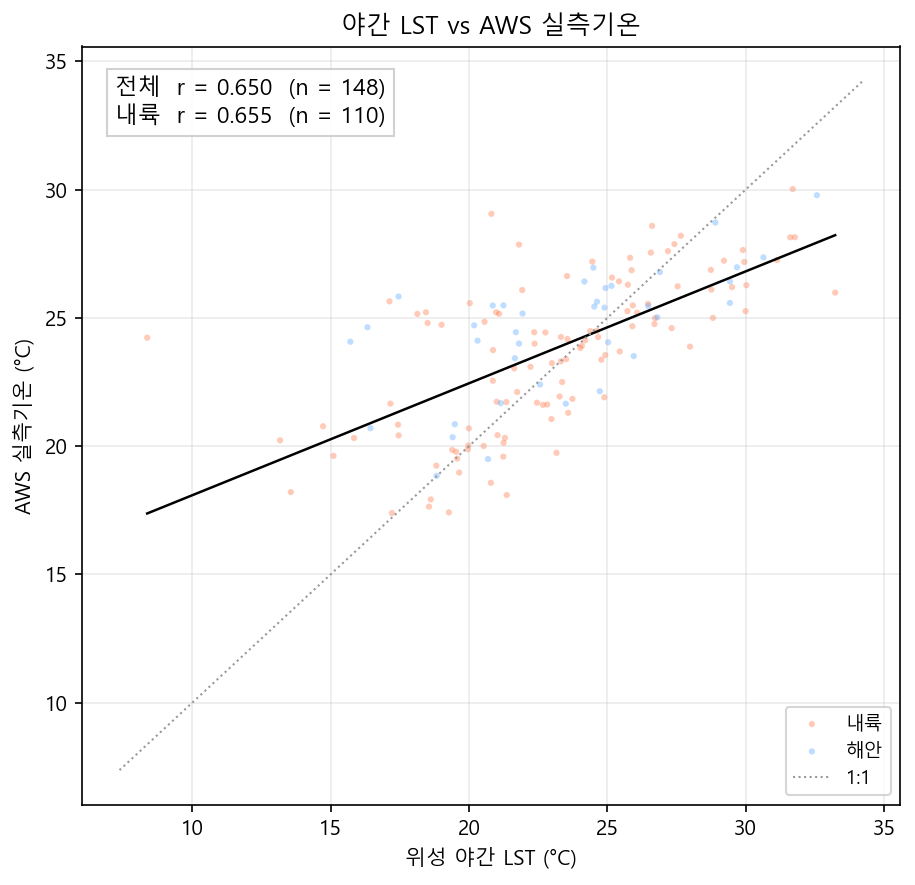

In [12]:
import matplotlib
import matplotlib.pyplot as plt

for f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):
    if f in {x.name for x in matplotlib.font_manager.fontManager.ttflist}:
        matplotlib.rcParams["font.family"] = f
        break
matplotlib.rcParams["axes.unicode_minus"] = False


def plot_scatter(df: pd.DataFrame, res_all, res_inland, path: Path):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(6.2, 6.0), dpi=150)
    for flag, color, lab in ((False, "#ff6b35", "내륙"), (True, "#4a9eff", "해안")):
        d = df[df.is_coastal.fillna(False) == flag]
        if len(d):
            ax.scatter(d.lst_c, d.ta_c, s=9, alpha=.35, c=color, edgecolors="none", label=lab)
    d = df.dropna(subset=["lst_c", "ta_c"])
    if len(d) > 2:
        b, a = np.polyfit(d.lst_c, d.ta_c, 1)
        xs = np.linspace(d.lst_c.min(), d.lst_c.max(), 50)
        ax.plot(xs, b * xs + a, "k-", lw=1.2)
    lo = min(d.lst_c.min(), d.ta_c.min()) - 1
    hi = max(d.lst_c.max(), d.ta_c.max()) + 1
    ax.plot([lo, hi], [lo, hi], color="#999", ls=":", lw=1, label="1:1")
    txt = f"전체  r = {res_all.r_pearson:.3f}  (n = {res_all.n_pairs:,})"
    if res_inland:
        txt += f"\n내륙  r = {res_inland.r_pearson:.3f}  (n = {res_inland.n_pairs:,})"
    ax.text(.04, .96, txt, transform=ax.transAxes, va="top", fontsize=11,
            bbox=dict(fc="white", ec="#ccc", alpha=.9))
    ax.set_xlabel("위성 야간 LST (°C)")
    ax.set_ylabel("AWS 실측기온 (°C)")
    ax.set_title("야간 LST vs AWS 실측기온")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=.25)
    fig.tight_layout()
    fig.savefig(path)
    print("saved:", path)
    plt.show()


if len(matchup) and "r_night_all" in results:
    plot_scatter(subset(matchup, "night"), results["r_night_all"],
                 results.get("r_night_inland"), REPORTS / "part3_scatter.png")

In [13]:
STN_COLS = ["stn_id", "stn_name", "lon", "lat", "elev_m", "x_5186", "y_5186",
            "hex_id", "is_coastal", "dem_elev_m", "n_valid"]

if len(stations):
    n_valid = (matchup.groupby("stn_id").size().rename("n_valid").reset_index()
               if len(matchup) else pd.DataFrame({"stn_id": [], "n_valid": []}))
    stn_out = stations.merge(n_valid, on="stn_id", how="left")
    stn_out["n_valid"] = stn_out["n_valid"].fillna(0).astype(int)
    for c in STN_COLS:
        if c not in stn_out:
            stn_out[c] = pd.NA
    stn_out[STN_COLS].to_csv(OUT / "part3_stations.csv", index=False, encoding="utf-8-sig")
    print("saved:", OUT / "part3_stations.csv")

if len(matchup):
    MU_COLS = ["obs_time_kst", "sensor", "stn_id", "lst_c", "ta_c", "n_px_valid"]
    matchup[MU_COLS].to_parquet(OUT / "part3_matchup.parquet", index=False)
    print("saved:", OUT / "part3_matchup.parquet")
    for label, sr in scene_r.items():
        if len(sr):
            sr.to_csv(OUT / f"part3_scene_r_{label}.csv", index=False)

summary = {
    "generated_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "grid": {"crs": CRS_GRID, "res_m": GRID_RES, "shape": [GRID_H, GRID_W], "bounds": GRID_BOUNDS},
    "params": {"window": f"{2*WIN+1}x{2*WIN+1}", "min_valid_px": MIN_VALID_PX,
               "max_gap_h": MAX_GAP_H, "coastal_dist_m": COASTAL_DIST_M},
    "correlations": {k: asdict(v) for k, v in results.items()},
    "scene_r": {k: {"median": float(v.r.median()), "q25": float(v.r.quantile(.25)),
                    "q75": float(v.r.quantile(.75)), "n_scenes": int(len(v))}
                for k, v in scene_r.items() if len(v)},
    "lapse_aws_night": lapse_night,
    "lapse_aws_night_inland": lapse_night_inland,
    "lapse_part1_night": LAPSE_P1_NIGHT,
    "lapse_part1_day": LAPSE_P1_DAY,
    "heat_stats": heat_stats,
    "n_stations": int(len(stations)),
    "n_pairs_total": int(len(matchup)),
}
(OUT / "part3_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("saved:", OUT / "part3_summary.json")

saved: ..\data\part3\part3_stations.csv


saved: ..\data\part3\part3_matchup.parquet
saved: ..\data\part3\part3_summary.json


## 8. 파트 5 인계 — 보고서 문장 자동 생성

파트 3의 산출물은 회귀 모델 변수가 아니라 **방법론 절의 문장**이 된다.

> ⚠️ `elev_m`은 회귀 설명변수로 쓰지 않는다. anomaly 생성에 이미 사용됐으므로 순환논리가 된다.
> 파트 3에서 고도는 **감률 검산에만** 쓴다.

In [14]:
def report_sentence() -> str:
    if "r_night_all" not in results:
        return "(데이터 확보 후 자동 생성)"
    r = results["r_night_all"]
    s = (f"위성 야간 LST는 부산 시내 AWS {r.n_stations}개 지점 실측기온과 "
         f"r = {r.r_pearson:.3f} (n = {r.n_pairs:,})의 상관을 보여, "
         f"지표면온도가 대기온도의 공간 패턴을 대변함을 확인했다.")
    if "r_night_inland" in results:
        s += (f" 해안 지점을 제외한 내륙 지점만으로는 r = "
              f"{results['r_night_inland'].r_pearson:.3f}였다.")
    if lapse_night:
        s += (f" 또한 AWS 고도별 기온 감률({lapse_night['lapse_c_per_100m']:+.3f}°C/100m)은 "
              f"위성 기반 감률({LAPSE_P1_NIGHT:+.3f}°C/100m)과 부합하여 "
              f"표고 보정(detrending)의 타당성을 뒷받침한다.")
    if heat_stats:
        s += (f" 최근 10년({heat_stats['period']}) 부산의 연평균 폭염일수는 "
              f"{heat_stats['heat_days_mean']:.1f}일, 열대야일수는 "
              f"{heat_stats['tropical_nights_mean']:.1f}일이다.")
    return s


print(report_sentence())

위성 야간 LST는 부산 시내 AWS 12개 지점 실측기온과 r = 0.650 (n = 148)의 상관을 보여, 지표면온도가 대기온도의 공간 패턴을 대변함을 확인했다. 해안 지점을 제외한 내륙 지점만으로는 r = 0.655였다. 또한 AWS 고도별 기온 감률(-0.539°C/100m)은 위성 기반 감률(-0.496°C/100m)과 부합하여 표고 보정(detrending)의 타당성을 뒷받침한다. 최근 10년(2016-2025) 부산의 연평균 폭염일수는 9.1일, 열대야일수는 29.0일이다.


## 9. 최종 검산 체크리스트

| 확인 항목 | 기대값 | 어긋나면 |
|---|---|---|
| 00~05시 관측의 실측기온 | 20°C대 (30°C 초과 5% 미만) | UTC/KST 9시간 어긋남 |
| 주간 bias (LST − Ta) | +10~20°C (정상) | 스택 단위(K/°C) 확인 |
| 야간 bias | −3 ~ +3°C 부근 | 지점 좌표/격자 정렬 |
| 야간 r | ≥ 0.5 | 5장 판정표 순서대로 의심 |
| 내륙 r vs 전체 r | 내륙이 더 높음 | 해안 판정(dist_water_m) 재확인 |
| 감률 부호 | 음수 (고도↑ → 기온↓) | 고도 범위·해안 지점 영향 |

In [15]:
def final_checks() -> pd.DataFrame:
    rows = []

    def add(name, ok, detail):
        rows.append({"항목": name, "통과": ok, "내용": detail})

    if len(matchup):
        n = subset(matchup, "night")
        d = subset(matchup, "day")
        if len(n):
            deep = n[n.obs_time_kst.dt.hour.isin([0, 1, 2, 3, 4, 5])]
            # 2026-09-17: 새벽 관측이 0건이면 검산 자체가 불가 → 실패로 본다(예전엔 nan 이 통과로 처리됐다)
            hot = float((deep.ta_c > 30).mean()) if len(deep) else np.nan
            add("시간대 검산", bool(len(deep) > 0 and hot < 0.05),
                f"새벽(00~05시) 관측 {len(deep)}쌍 · 30°C초과 비율 {hot:.1%}")
            b = float((n.lst_c - n.ta_c).mean())
            add("야간 bias", abs(b) < 5, f"{b:+.2f} °C")
        if len(d):
            b = float((d.lst_c - d.ta_c).mean())
            add("주간 bias", b > 0, f"{b:+.2f} °C (양수가 정상)")
        add("n_px_valid 하한", bool((matchup.n_px_valid >= MIN_VALID_PX).all()),
            f"최소 {int(matchup.n_px_valid.min())}")
    if "r_night_all" in results:
        r = results["r_night_all"].r_pearson
        add("야간 r ≥ 0.5", r >= 0.5, f"{r:.3f}")
    if "r_night_inland" in results and "r_night_all" in results:
        add("내륙 r > 전체 r",
            results["r_night_inland"].r_pearson > results["r_night_all"].r_pearson,
            f"{results['r_night_inland'].r_pearson:.3f} vs {results['r_night_all'].r_pearson:.3f}")
    if lapse_night:
        add("감률 부호 일치", np.sign(lapse_night["lapse_c_per_100m"]) == np.sign(LAPSE_P1_NIGHT),
            f"{lapse_night['lapse_c_per_100m']:+.3f} vs {LAPSE_P1_NIGHT:+.3f}")

    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=["항목", "통과", "내용"])


checks = final_checks()
display(checks)
if len(checks) and not checks["통과"].all():
    print("\n[!] 실패 항목이 있습니다. 가이드 4장(조심할 것 5가지)을 순서대로 확인하세요.")

,항목,통과,내용
0,시간대 검산,True,새벽(00~05시) 관측 103쌍 · 30°C초과 비율 0.0%
1,야간 bias,True,-0.66 °C
2,주간 bias,True,+6.42 °C (양수가 정상)
3,n_px_valid 하한,True,최소 5
4,야간 r ≥ 0.5,True,0.650
5,내륙 r > 전체 r,True,0.655 vs 0.650
6,감률 부호 일치,True,-0.539 vs -0.496


## 부록 — AWS 추가 데이터(지점 12개) 병합

`data/part3/AWS/AWS 추가/` 밑에 지점별 CSV 12개(지점 160·904·910·921·923·937~942·950,
2020~2025년 각 6~8월 시간자료). 컬럼은 지점·일시·기온·풍향·풍속·강수량·습도로 12개 파일 모두 동일.

병합을 막을 수 있는 **구조적 문제**(컬럼 불일치, 지점 내 중복 시각)와,
막지는 않지만 알아둬야 할 **결측**(컬럼별 NaN, 관측 자체가 빠진 시간대)을 나눠서 먼저 확인한다.

In [16]:
AWS_EXTRA_DIR = Path("../data/part3/AWS/AWS 추가")
aws_extra_files = sorted(AWS_EXTRA_DIR.glob("*.csv"))
print(f"{len(aws_extra_files)}개 파일 발견:", [f.name for f in aws_extra_files])


def expected_hourly_index(years=range(2020, 2026), month_start=6, month_end=8):
    parts = [pd.date_range(f"{y}-{month_start:02d}-01 00:00", f"{y}-{month_end:02d}-31 23:00", freq="h")
             for y in years]
    return pd.DatetimeIndex(np.concatenate(parts))


EXPECTED_IDX = expected_hourly_index()

aws_extra_frames = {}
check_rows = []
for f in aws_extra_files:
    df = pd.read_csv(f, encoding="utf-8-sig")
    df["일시"] = pd.to_datetime(df["일시"])
    aws_extra_frames[f.name] = df
    na = df.isna().sum()
    check_rows.append({
        "파일": f.name,
        "지점": int(df["지점"].iloc[0]),
        "행수": len(df),
        "기간": f'{df["일시"].min():%Y-%m-%d} ~ {df["일시"].max():%Y-%m-%d}',
        "관측 자체 결측(행 없음)": len(EXPECTED_IDX) - len(df),
        "중복 시각": int(df["일시"].duplicated().sum()),
        "기온 NA": int(na.get("기온", 0)),
        "풍향 NA": int(na.get("풍향", 0)),
        "풍속 NA": int(na.get("풍속", 0)),
        "강수량 NA": int(na.get("강수량", 0)),
        "습도 NA": int(na.get("습도", 0)),
    })

check_tbl = pd.DataFrame(check_rows)
display(check_tbl)

# ── 병합을 막을 만한 구조적 문제만 assert로 확인 ────────────────────────────
col_sets = {name: tuple(df.columns) for name, df in aws_extra_frames.items()}
assert len(set(col_sets.values())) == 1, f"파일마다 컬럼 구성이 다름: {col_sets}"
assert (check_tbl["중복 시각"] == 0).all(), "지점 내 중복 시각 존재 — 병합 전 처리 필요"
assert check_tbl["지점"].nunique() == len(check_tbl), "같은 지점 번호가 여러 파일에 중복 — 확인 필요"

na_rate = check_tbl[["기온 NA", "풍향 NA", "풍속 NA", "강수량 NA", "습도 NA"]].div(check_tbl["행수"], axis=0)
high_na = check_tbl.loc[(na_rate > 0.15).any(axis=1), "파일"].tolist()
if high_na:
    print(f"[참고] 결측률 15% 넘는 컬럼이 있는 파일(주로 습도 센서 결측으로 보임): {high_na}")

print("\n[ok] 12개 파일 컬럼 구성 동일 · 지점 내 시각 중복 없음 · 지점번호 중복 없음"
      " — 결측값 자체는 있지만(계측기 정지 등 AWS 자료의 정상적 특성) 병합을 막는 구조적 문제는 없음")

12개 파일 발견: ['AWS2020_2025.csv', 'AWS904_2020_2025.csv', 'AWS910_2020_2025.csv', 'AWS921_2020_2025.csv', 'AWS923_2020_2025.csv', 'AWS937_2020_2025.csv', 'AWS938_2020_2025.csv', 'AWS939_2020_2025.csv', 'AWS940_2020_2025.csv', 'AWS941_2020_2025.csv', 'AWS942_2020_2025.csv', 'AWS950_2020_2025.csv']


,파일,지점,행수,기간,관측 자체 결측(행 없음),중복 시각,기온 NA,풍향 NA,풍속 NA,강수량 NA,습도 NA
0,AWS2020_2025.csv,160,13185,2020-06-01 ~ 2025-08-31,63,0,34,304,70,270,84
1,AWS904_2020_2025.csv,904,13245,2020-06-01 ~ 2025-08-31,3,0,2,53,57,92,2
2,AWS910_2020_2025.csv,910,13170,2020-06-01 ~ 2025-08-31,78,0,10,17,17,233,38
3,AWS921_2020_2025.csv,921,13245,2020-06-01 ~ 2025-08-31,3,0,3,35,35,86,2
4,AWS923_2020_2025.csv,923,13229,2020-06-01 ~ 2025-08-31,19,0,11,30,30,131,10
5,AWS937_2020_2025.csv,937,13137,2020-06-01 ~ 2025-08-31,111,0,12,33,19,175,12
6,AWS938_2020_2025.csv,938,13199,2020-06-01 ~ 2025-08-31,49,0,3,8,8,43,2160
7,AWS939_2020_2025.csv,939,13224,2020-06-01 ~ 2025-08-31,24,0,12,83,83,227,272
8,AWS940_2020_2025.csv,940,13232,2020-06-01 ~ 2025-08-31,16,0,4,51,57,232,7
9,AWS941_2020_2025.csv,941,13229,2020-06-01 ~ 2025-08-31,19,0,7,9,6,55,2198


[참고] 결측률 15% 넘는 컬럼이 있는 파일(주로 습도 센서 결측으로 보임): ['AWS938_2020_2025.csv', 'AWS941_2020_2025.csv', 'AWS942_2020_2025.csv']

[ok] 12개 파일 컬럼 구성 동일 · 지점 내 시각 중복 없음 · 지점번호 중복 없음 — 결측값 자체는 있지만(계측기 정지 등 AWS 자료의 정상적 특성) 병합을 막는 구조적 문제는 없음


In [17]:
# 구조적 문제 없음 확인됨 → 12개 지점을 세로로 이어붙여 하나의 롱포맷 테이블로 병합
aws_extra_merged = (pd.concat(aws_extra_frames.values(), ignore_index=True)
                     .sort_values(["지점", "일시"])
                     .reset_index(drop=True))

print(f"병합 결과: {aws_extra_merged.shape[0]:,}행 x {aws_extra_merged.shape[1]}열, "
      f"지점 {aws_extra_merged['지점'].nunique()}개")
print("\n컬럼별 결측치:")
print(aws_extra_merged.isna().sum())

AWS_EXTRA_OUT = AWS_EXTRA_DIR.parent / "aws_hourly_merged_2020_2025.csv"
aws_extra_merged.to_csv(AWS_EXTRA_OUT, index=False, encoding="utf-8-sig")
print("\nsaved:", AWS_EXTRA_OUT)

병합 결과: 158,428행 x 7열, 지점 12개

컬럼별 결측치:
지점        0
일시        0
기온      129
풍향      738
풍속      485
강수량    1781
습도     8248
dtype: int64



saved: ..\data\part3\AWS\aws_hourly_merged_2020_2025.csv
